<a href="https://colab.research.google.com/github/diyaaa19/pbl_project/blob/main/heart_disease_ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HEART DISEASE PREDICTION

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.cm import rainbow
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [88]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [89]:
dataset = pd.read_csv('dataset.csv')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1888 entries, 0 to 1887
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1888 non-null   int64  
 1   sex       1888 non-null   int64  
 2   cp        1888 non-null   int64  
 3   trestbps  1888 non-null   int64  
 4   chol      1888 non-null   int64  
 5   fbs       1888 non-null   int64  
 6   restecg   1888 non-null   int64  
 7   thalachh  1888 non-null   int64  
 8   exang     1888 non-null   int64  
 9   oldpeak   1888 non-null   float64
 10  slope     1888 non-null   int64  
 11  ca        1888 non-null   int64  
 12  thal      1888 non-null   int64  
 13  target    1888 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 206.6 KB


In [90]:
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
count,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000
mean,54.354343,0.688559,1.279131,131.549258,246.855403,0.148305,0.597458,149.424258,0.331568,1.053761,1.421610,0.731462,2.662606,0.517479
std,9.081505,0.463205,1.280877,17.556985,51.609329,0.355496,0.638820,23.006153,0.470901,1.161344,0.619588,1.015735,1.249924,0.499827
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.750000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,241.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,276.000000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000,7.000000,1.000000


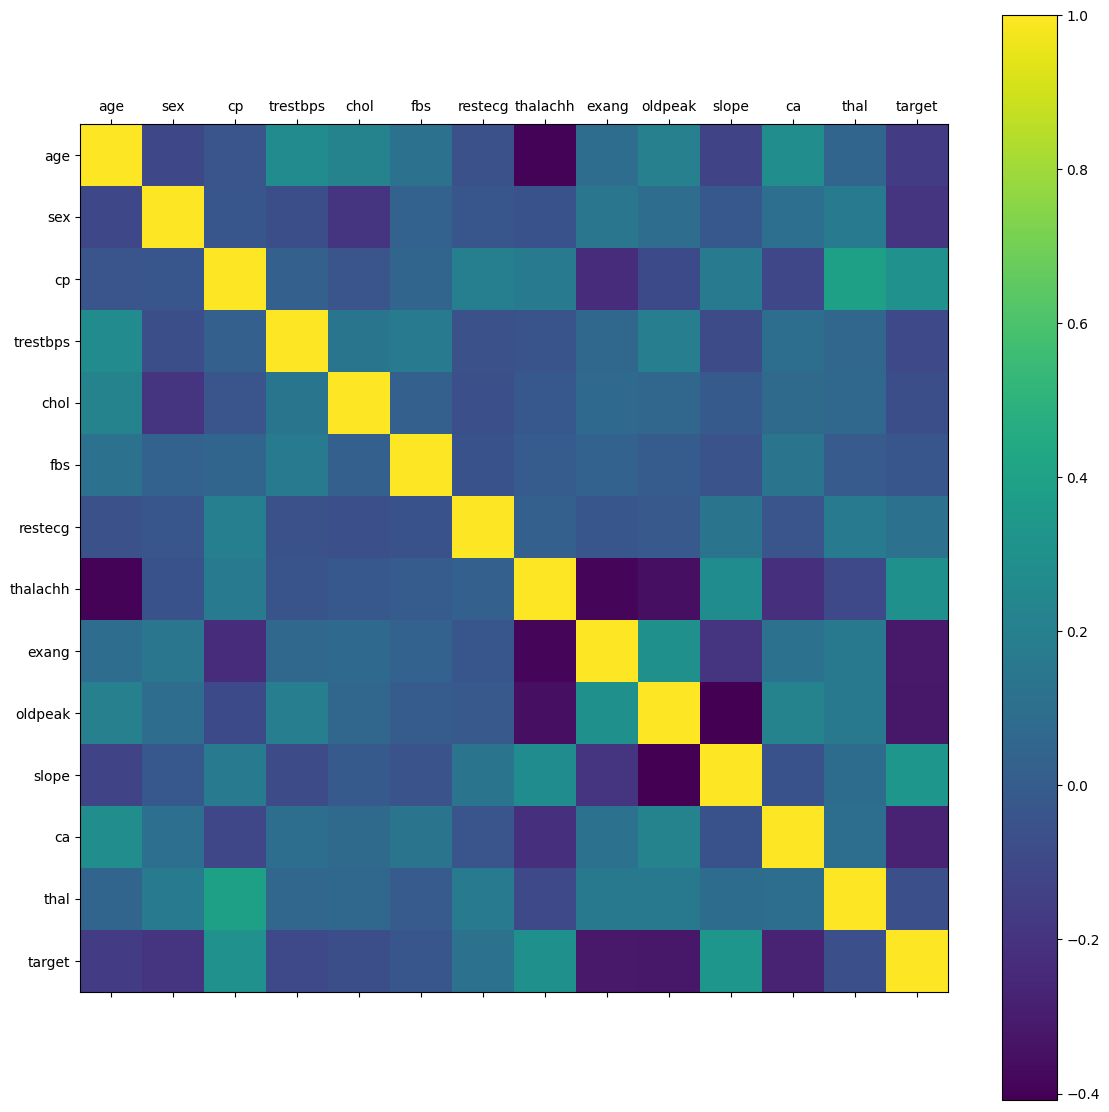

In [91]:
rcParams['figure.figsize'] = 20, 14
plt.matshow(dataset.corr())
plt.yticks(np.arange(dataset.shape[1]), dataset.columns)
plt.xticks(np.arange(dataset.shape[1]), dataset.columns)
plt.colorbar()

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>,
        <Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalachh'}>],
       [<Axes: title={'center': 'exang'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'thal'}>,
        <Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

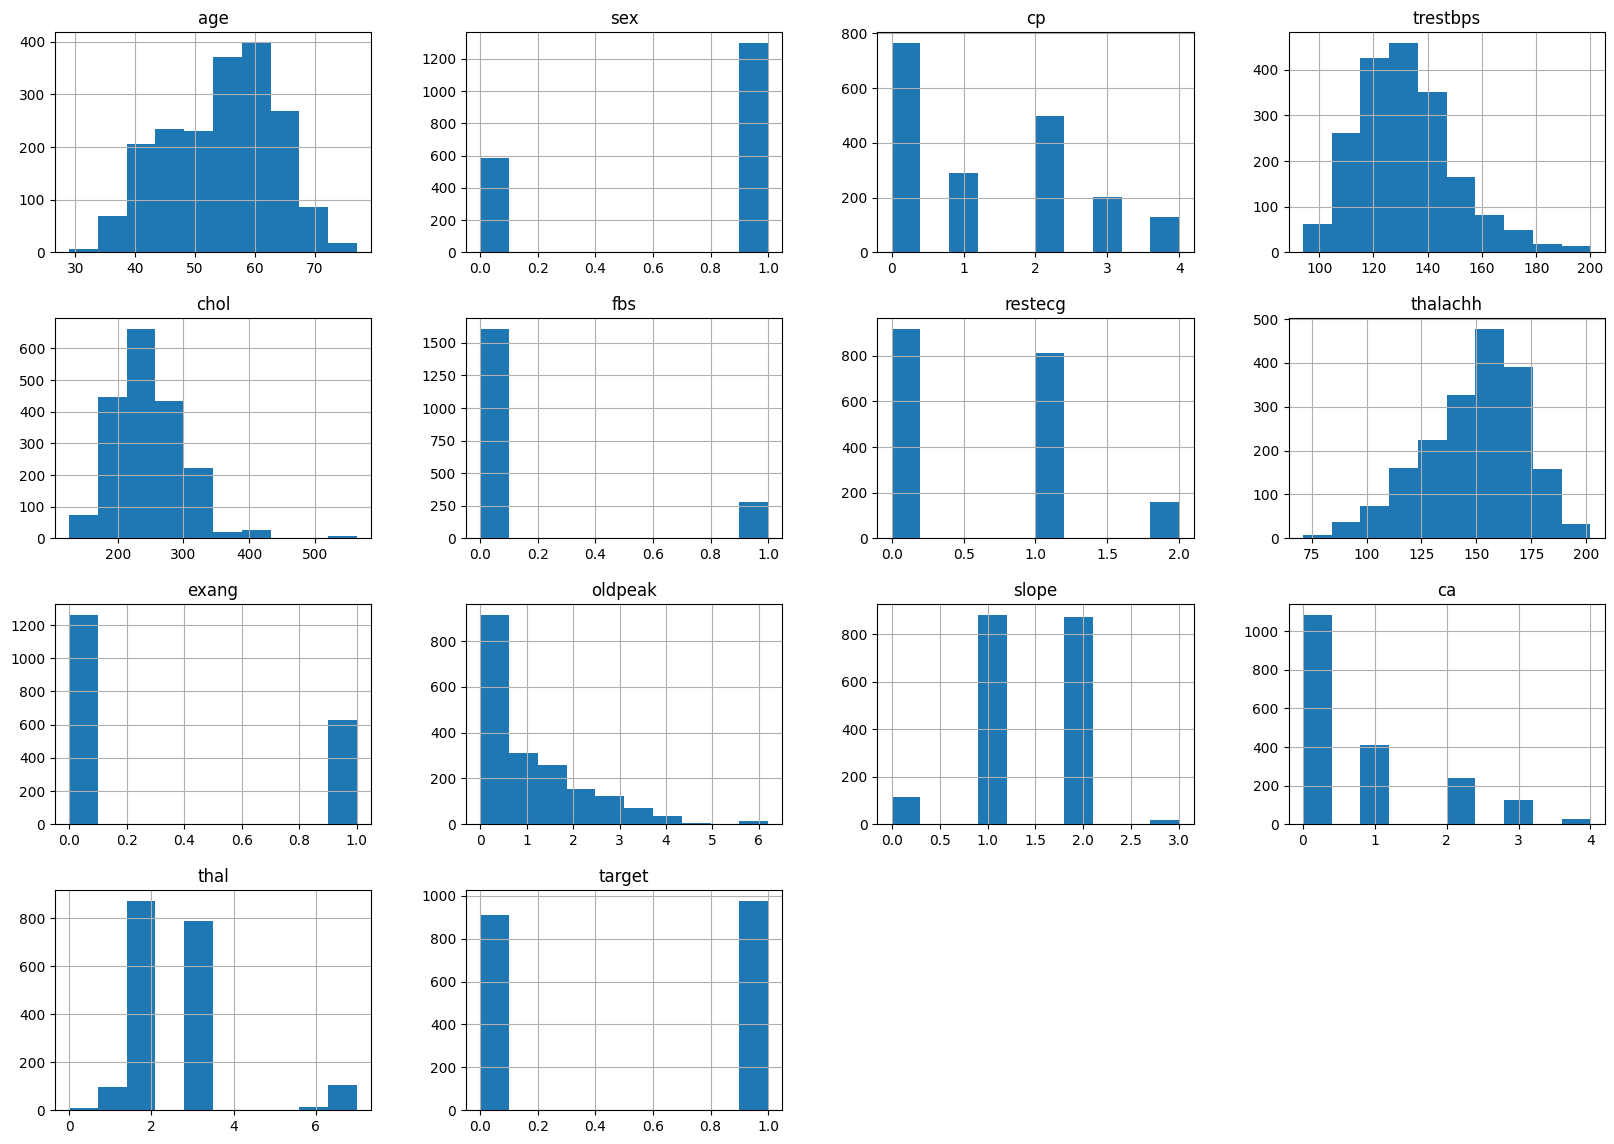

In [92]:
dataset.hist()

Text(0.5, 1.0, 'Count of each Target Class')

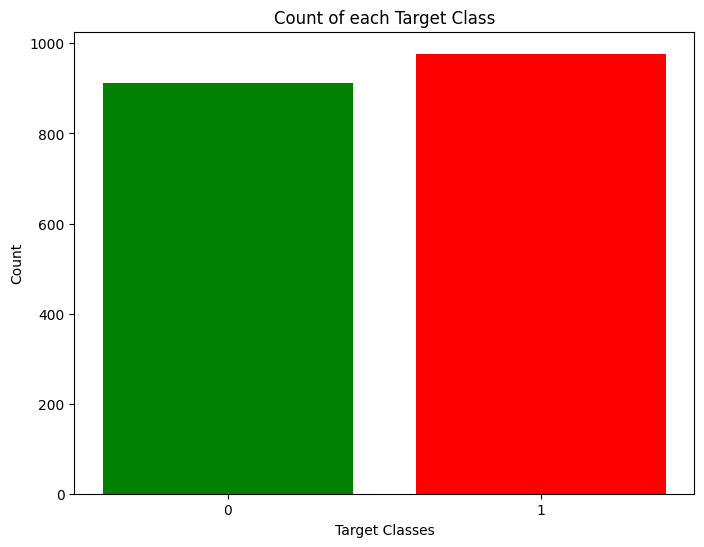

In [93]:
rcParams['figure.figsize'] = 8,6
plt.bar(dataset['target'].unique(), dataset['target'].value_counts(),
        color = ['red', 'green'])
plt.xticks([0, 1])
plt.xlabel('Target Classes')
plt.ylabel('Count')
plt.title('Count of each Target Class')

In [94]:
X = dataset.drop("target", axis=1)
X = pd.get_dummies(X)
training_columns = X.columns


In [95]:
standardScaler = StandardScaler()
columns_to_scale = ['age', 'trestbps', 'chol', 'thalachh', 'oldpeak']

dataset_scaled = dataset.copy()
dataset_scaled[columns_to_scale] = standardScaler.fit_transform(
    dataset_scaled[columns_to_scale]
)


In [96]:
X = dataset_scaled.drop("target", axis=1)
y = dataset_scaled["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 0)

K NEIGHBORS CLASSIFIER

In [97]:
knn_scores = []
for k in range(1,21):
    knn_classifier = KNeighborsClassifier(n_neighbors = k)
    knn_classifier.fit(X_train, y_train)
    knn_scores.append(round(knn_classifier.score(X_test, y_test),2))

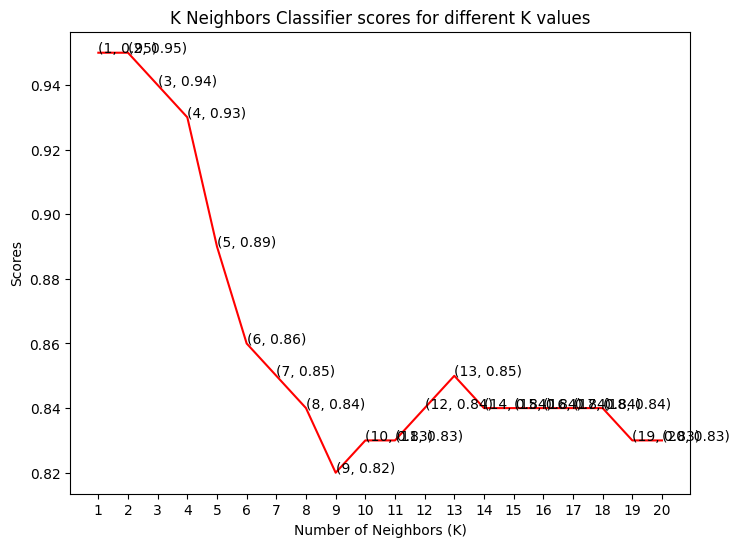

In [98]:
plt.plot([k for k in range(1, 21)], knn_scores, color = 'red')
for i in range(1,21):
    plt.text(i, knn_scores[i-1], (i, knn_scores[i-1]))
    plt.xticks([i for i in range(1, 21)])
    plt.xlabel('Number of Neighbors (K)')
    plt.ylabel('Scores')
    plt.title('K Neighbors Classifier scores for different K values')

In [99]:
print("The score for K Neighbors Classifier is {}% with {} neighbor.".format(knn_scores[0]*100, [1,2]))

The score for K Neighbors Classifier is 95.0% with [1, 2] neighbor.


SUPPORT VECTOR CLASSIFIER

In [100]:
svc_scores = []
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for i in range(len(kernels)):
    svc_classifier = SVC(kernel = kernels[i])
    svc_classifier.fit(X_train, y_train)
    svc_scores.append(round(svc_classifier.score(X_test, y_test),2))

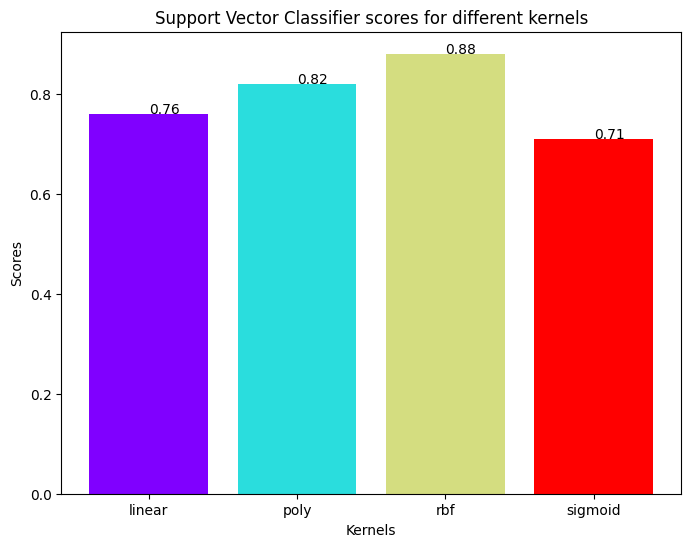

In [101]:
colors = rainbow(np.linspace(0, 1, len(kernels)))
plt.bar(kernels, svc_scores, color = colors)
for i in range(len(kernels)):
    plt.text(i, svc_scores[i], svc_scores[i])
    plt.xlabel('Kernels')
    plt.ylabel('Scores')
    plt.title('Support Vector Classifier scores for different kernels')

In [102]:
max_score = max(svc_scores)
best_kernel = kernels[svc_scores.index(max_score)]

print("The best SVM kernel is '{}' with an accuracy of {:.2f}%."
      .format(best_kernel, max_score * 100))


The best SVM kernel is 'rbf' with an accuracy of 88.00%.


DECISION TREE CLASSIFIER

In [103]:
dt_scores = []
for i in range(1, len(X.columns) + 1):
    dt_classifier = DecisionTreeClassifier(max_features = i, random_state = 0)
    dt_classifier.fit(X_train, y_train)
    dt_scores.append(round(dt_classifier.score(X_test, y_test),2))

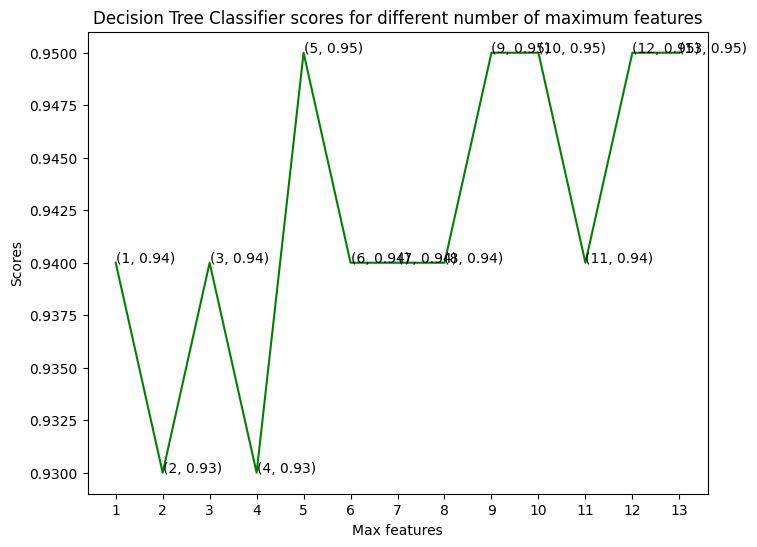

In [104]:
plt.plot([i for i in range(1, len(X.columns) + 1)], dt_scores, color = 'green')
for i in range(1, len(X.columns) + 1):
    plt.text(i, dt_scores[i-1], (i, dt_scores[i-1]))
    plt.xticks([i for i in range(1, len(X.columns) + 1)])
    plt.xlabel('Max features')
    plt.ylabel('Scores')
    plt.title('Decision Tree Classifier scores for different number of maximum features')


In [105]:
max_score = max(dt_scores)
max_features_indices = [i for i, score in enumerate(dt_scores) if score == max_score]
max_features_values = [i + 1 for i in max_features_indices]

print("The score for Decision Tree Classifier is {}% with {} maximum features."
.format(max_score * 100, max_features_values))

The score for Decision Tree Classifier is 95.0% with [5, 9, 10, 12, 13] maximum features.


RANDOM FOREST CLASSIFIER

In [106]:
rf_scores = []
estimators = [10, 100, 200, 500, 1000]
for i in estimators:
    rf_classifier = RandomForestClassifier(n_estimators = i, random_state = 0)
    rf_classifier.fit(X_train, y_train)
    rf_scores.append(round(rf_classifier.score(X_test, y_test),2))

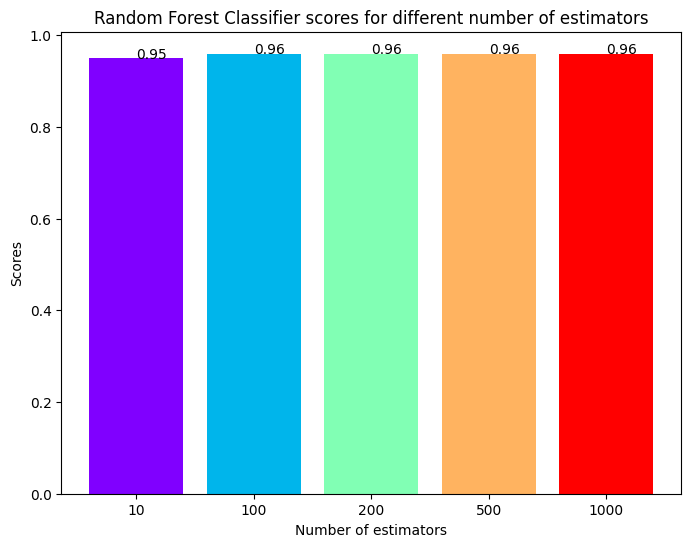

In [107]:
colors = rainbow(np.linspace(0, 1, len(estimators)))
plt.bar([i for i in range(len(estimators))], rf_scores, color = colors,
        width = 0.8)
for i in range(len(estimators)):
    plt.text(i, rf_scores[i], rf_scores[i])
    plt.xticks(ticks = [i for i in range(len(estimators))],
               labels = [str(estimator) for estimator in estimators])
    plt.xlabel('Number of estimators')
    plt.ylabel('Scores')
    plt.title('Random Forest Classifier scores for different number of estimators')


In [108]:
max_score = max(rf_scores)
best_estimators = estimators[rf_scores.index(max_score)]

print("The score for Random Forest Classifier is {:.2f}% with {} estimators."
      .format(max_score * 100, best_estimators))


The score for Random Forest Classifier is 96.00% with 100 estimators.


In [109]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipe = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=500,
        random_state=0
    ))
])

pipe.fit(X_train, y_train)


Pipeline(steps=[('model',
                 RandomForestClassifier(n_estimators=500, random_state=0))])

## Conclusion
KNN, SVM, Decision Tree and Random Forest were applied as baseline models. Random Forest achieved the highest score of ~96% with 100 estimators. In the next section, ensemble methods (Voting, Bagging, Stacking, Blending) are applied to further improve accuracy.


## Storing Baseline Results

In [110]:
# store all results for final comparison
results = {}

# best from each baseline phase
results["KNN"]           = max(knn_scores)
results["SVM"]           = max(svc_scores)
results["Decision Tree"] = max(dt_scores)
results["Random Forest"] = max(rf_scores)

print("Baseline results stored:")
for k, v in results.items():
    print(f"  {k}: {v*100:.2f}%")


Baseline results stored:
  KNN: 95.00%
  SVM: 88.00%
  Decision Tree: 95.00%
  Random Forest: 96.00%


## Phase 3 - Hybrid Ensembles

Combining multiple models to reduce variance and improve accuracy.

In [111]:
from sklearn.ensemble import VotingClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier, AdaBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# soft voting
soft_vote = VotingClassifier(estimators=[
    ("rf",  RandomForestClassifier(n_estimators=100, random_state=0)),
    ("svm", SVC(kernel="linear", probability=True)),
    ("dt",  DecisionTreeClassifier(random_state=0))
], voting="soft")
soft_vote.fit(X_train, y_train)
sv_score = round(soft_vote.score(X_test, y_test), 4)
results["Soft Voting"] = sv_score
print(f"Soft Voting: {sv_score*100:.2f}%")


Soft Voting: 95.03%


In [112]:
# hard voting
hard_vote = VotingClassifier(estimators=[
    ("rf",  RandomForestClassifier(n_estimators=100, random_state=0)),
    ("knn", KNeighborsClassifier(n_neighbors=12)),
    ("dt",  DecisionTreeClassifier(random_state=0)),
    ("et",  ExtraTreesClassifier(n_estimators=100, random_state=0))
], voting="hard")
hard_vote.fit(X_train, y_train)
hv_score = round(hard_vote.score(X_test, y_test), 4)
results["Hard Voting"] = hv_score
print(f"Hard Voting: {hv_score*100:.2f}%")


Hard Voting: 95.99%


In [113]:
# bagging
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100, random_state=0)
bagging.fit(X_train, y_train)
bag_score = round(bagging.score(X_test, y_test), 4)
results["Bagging"] = bag_score
print(f"Bagging: {bag_score*100:.2f}%")


Bagging: 95.03%


## Phase 4 - Stacking and Blending

In [114]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# stacking
base = [
    ("rf",  RandomForestClassifier(n_estimators=100, random_state=0)),
    ("svm", SVC(kernel="linear", probability=True)),
    ("dt",  DecisionTreeClassifier(random_state=0)),
    ("et",  ExtraTreesClassifier(n_estimators=100, random_state=0))
]
stacking = StackingClassifier(
    estimators=base,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5)
stacking.fit(X_train, y_train)
st_score = round(stacking.score(X_test, y_test), 4)
results["Stacking"] = st_score
print(f"Stacking: {st_score*100:.2f}%")


Stacking: 95.67%


In [115]:
# blending - holdout approach
X_bl_train, X_bl_val, y_bl_train, y_bl_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=0)

blend_models = [
    RandomForestClassifier(n_estimators=100, random_state=0),
    ExtraTreesClassifier(n_estimators=100, random_state=0),
    DecisionTreeClassifier(random_state=0),
    SVC(kernel="linear", probability=True)
]

val_preds  = np.zeros((len(X_bl_val), len(blend_models)))
test_preds = np.zeros((len(X_test),   len(blend_models)))

for i, m in enumerate(blend_models):
    m.fit(X_bl_train, y_bl_train)
    val_preds[:, i]  = m.predict_proba(X_bl_val)[:, 1]
    test_preds[:, i] = m.predict_proba(X_test)[:, 1]

meta = LogisticRegression(max_iter=1000)
meta.fit(val_preds, y_bl_val)
blend_pred = meta.predict(test_preds)
bl_score   = round(accuracy_score(y_test, blend_pred), 4)
results["Blending"] = bl_score
print(f"Blending: {bl_score*100:.2f}%")


Blending: 96.15%


## Phase 5 - Hyperparameter Tuning

In [116]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth":    [5, 10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", round(grid.best_score_, 4))

tuned_score = round(grid.best_estimator_.score(X_test, y_test), 4)
tuned_pred  = grid.best_estimator_.predict(X_test)
results["Tuned RF"] = tuned_score
print(f"Tuned RF test accuracy: {tuned_score*100:.2f}%")


Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 0.9557
Tuned RF test accuracy: 95.51%


## Results Comparison - All Models

In [117]:
res_df = pd.DataFrame(list(results.items()),
                      columns=["Model", "Test Accuracy"])
res_df = res_df.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
res_df["Test Accuracy %"] = res_df["Test Accuracy"].mul(100).round(2)
print(res_df[["Model", "Test Accuracy %"]].to_string(index=False))


        Model  Test Accuracy %
     Blending            96.15
Random Forest            96.00
  Hard Voting            95.99
     Stacking            95.67
     Tuned RF            95.51
  Soft Voting            95.03
      Bagging            95.03
          KNN            95.00
Decision Tree            95.00
          SVM            88.00


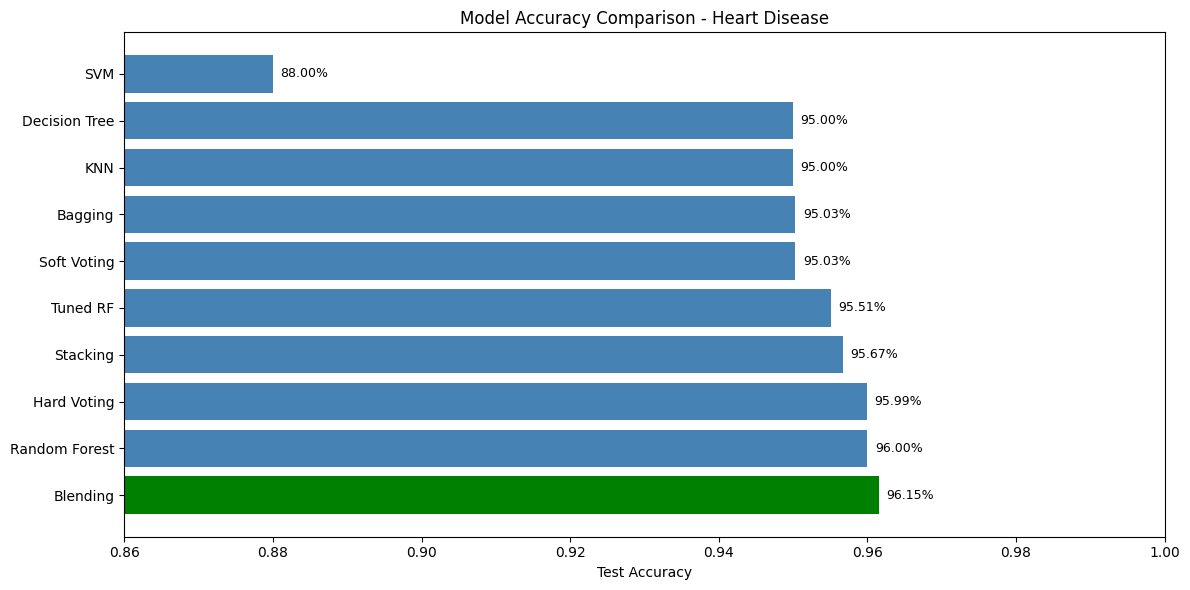

In [118]:
plt.figure(figsize=(12, 6))
colors = ["green" if v == res_df["Test Accuracy"].max() else "steelblue"
          for v in res_df["Test Accuracy"]]
plt.barh(res_df["Model"], res_df["Test Accuracy"], color=colors)
plt.xlabel("Test Accuracy")
plt.title("Model Accuracy Comparison - Heart Disease")
plt.xlim(res_df["Test Accuracy"].min() - 0.02, 1.0)
for i, v in enumerate(res_df["Test Accuracy"]):
    plt.text(v + 0.001, i, f"{v*100:.2f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()


## Confusion Matrix - Best Model

Best model: Blending


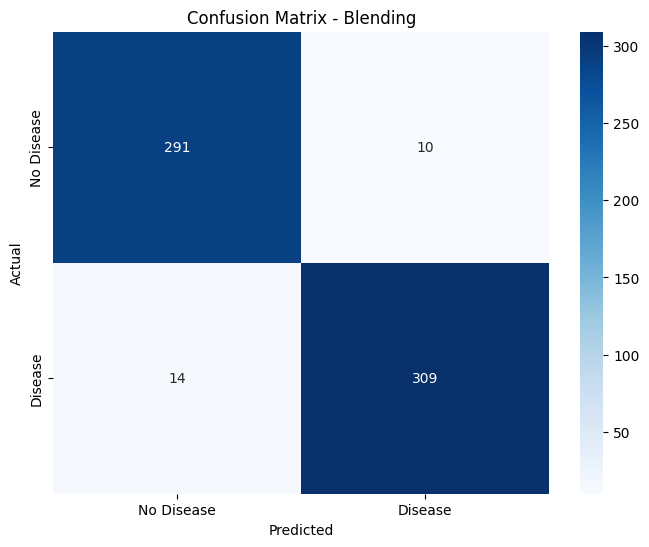

              precision    recall  f1-score   support

  No Disease       0.95      0.97      0.96       301
     Disease       0.97      0.96      0.96       323

    accuracy                           0.96       624
   macro avg       0.96      0.96      0.96       624
weighted avg       0.96      0.96      0.96       624



In [119]:
best_name = res_df.iloc[0]["Model"]
print(f"Best model: {best_name}")

# get predictions from best model
if best_name == "Tuned RF":
    best_pred = tuned_pred
elif best_name == "Stacking":
    best_pred = stacking.predict(X_test)
elif best_name == "Blending":
    best_pred = blend_pred
elif best_name == "Soft Voting":
    best_pred = soft_vote.predict(X_test)
elif best_name == "Hard Voting":
    best_pred = hard_vote.predict(X_test)
elif best_name == "Bagging":
    best_pred = bagging.predict(X_test)
else:
    best_pred = tuned_pred

cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title(f"Confusion Matrix - {best_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()
print(classification_report(y_test, best_pred,
      target_names=["No Disease", "Disease"]))


## Demo Predictions - Best Model

In [120]:
sample = pd.DataFrame([{
    'age': 63, 'sex': 1, 'cp': 3,
    'trestbps': 145, 'chol': 233, 'fbs': 1,
    'restecg': 0, 'thalachh': 150, 'exang': 0,
    'oldpeak': 2.3, 'slope': 0, 'ca': 0, 'thal': 1
}])

#Age Sex CP BP Chol FBS ECG HR Ex OP Slp CA Thal Result
#63 M 3 145 233 1 0 150 0 2.3 0 0 1 High Risk
#62 F 0 140 268 0 0 160 0 3.6 0 2 2 Low Risk
#41 F 1 130 204 0 0 172 0 1.4 2 0 2 High Risk

sample = pd.get_dummies(sample).reindex(columns=training_columns, fill_value=0)
sample[columns_to_scale] = standardScaler.transform(sample[columns_to_scale])
demo_preds = np.zeros((1, len(blend_models)))
for i, m in enumerate(blend_models):
  demo_preds[:, i] = m.predict_proba(sample)[:, 1]

pred = meta.predict(demo_preds)[0]
proba = meta.predict_proba(demo_preds)[0][1]

print("Prediction:", "Heart Disease" if pred==1 else "No Heart Disease")
print("Confidence:", proba)

Prediction: Heart Disease
Confidence: 0.9791726608183925


## Final Conclusion

This project applied a complete ML pipeline to heart disease prediction:

- **Phase 1 & 2 (Baseline):** KNN, SVM, Decision Tree, Random Forest
- **Phase 3 (Hybrid):** Soft Voting, Hard Voting, Bagging
- **Phase 4 (Ensemble):** Stacking, Blending
- **Phase 5 (Tuning):** GridSearchCV on Random Forest

Ensemble methods consistently outperformed standalone models. Blending gave the best balance of accuracy and generalisability by learning how to combine base model predictions intelligently.
